# 05 — Expresso Backtest (DAX 40)

## Strategy concept
The **Expresso** is the "quick shot" version of the School Run: instead of waiting for the
**4th** 5-min candle (09:15 CET), we use the **1st** 5-min candle that closes at **09:05 CET**
as the signal bar — maximum freshness, minimum information, maximum speed.

The entry mechanics are identical to ASRS:
- Buy-stop at `signal_high + BUFFER`
- Sell-stop at `signal_low  − BUFFER`  (OCO)
- Stop loss = opposite entry price (signal range + 2×BUFFER risk)
- No profit target — let the winner run to EOD (17:30 CET)

## What we test
| # | Study | Description |
|---|-------|-------------|
| S1 | Raw Expresso (1st bar) | No filters — full universe |
| S2 | Range filter | Only trade when 1st-bar range is 10–55 pts |
| S3 | No Friday | Skip Fridays (F1 from ASRS) |
| S4 | Month filter | Skip January, July, August (C4 from ASRS) |
| S5 | Best combo | S2 + S3 + S4 |
| S6 | Expresso vs ASRS | Head-to-head on same filtered universe |

> **Baseline reference (ASRS F1+F2+C4)**: Sharpe 1.23, PF 1.27, +9,278 pts, MaxDD −1,112

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

print(f'ROOT = {ROOT}')

ROOT = C:\Users\ali\Desktop\Projet-INFO-2AS2


## 1. Load Data

In [2]:
DATA_PATH = ROOT / 'data' / 'dax-5m_bk.csv'

raw = pd.read_csv(
    DATA_PATH, sep=';', header=None,
    names=['date', 'time', 'open', 'high', 'low', 'close', 'volume'],
)
raw['datetime'] = pd.to_datetime(raw['date'] + ' ' + raw['time'], format='%d/%m/%Y %H:%M')
raw = raw.drop(columns=['date', 'time']).set_index('datetime').sort_index()

START_DATE = '2006-01-01'
raw = raw[raw.index >= START_DATE]

print(f'Loaded {len(raw):,} rows  {raw.index[0].date()} → {raw.index[-1].date()}')

Loaded 998,622 rows  2006-01-02 → 2026-04-06


## 2. Parameters

In [3]:
# ── Expresso signal bar ────────────────────────────────────────────────────────
EXPRESSO_BAR_TIME = '09:00'   # 1st 5-min candle of the DAX session (closes 09:05)
AFTER_SIGNAL_TIME = '09:05'   # bars available for entry after signal bar closes

# ── ASRS reference bar (for head-to-head comparison) ──────────────────────────
ASRS_BAR_TIME     = '09:15'   # 4th 5-min candle (closes 09:20)
ASRS_AFTER_TIME   = '09:20'

# ── Shared execution parameters ───────────────────────────────────────────────
ENTRY_BUFFER  = 2       # pts beyond signal bar high / low
EOD_EXIT_TIME = '17:30' # CET

# ── Filters ───────────────────────────────────────────────────────────────────
RANGE_MIN      = 10     # minimum signal bar range (pts)
RANGE_MAX      = 55     # maximum signal bar range (pts)
SKIP_DOW       = [4]    # Fridays
SKIP_MONTHS    = [1, 7, 8]  # January, July, August

print('Parameters set.')
print(f'  Expresso signal bar : {EXPRESSO_BAR_TIME} CET (closes 09:05)')
print(f'  ASRS signal bar     : {ASRS_BAR_TIME} CET (closes 09:20)')
print(f'  Entry buffer        : ±{ENTRY_BUFFER} pts')
print(f'  EOD exit            : {EOD_EXIT_TIME} CET')
print(f'  Range filter        : {RANGE_MIN}–{RANGE_MAX} pts')
print(f'  Skip DOW            : Fridays')
print(f'  Skip months         : Jan, Jul, Aug')

Parameters set.
  Expresso signal bar : 09:00 CET (closes 09:05)
  ASRS signal bar     : 09:15 CET (closes 09:20)
  Entry buffer        : ±2 pts
  EOD exit            : 17:30 CET
  Range filter        : 10–55 pts
  Skip DOW            : Fridays
  Skip months         : Jan, Jul, Aug


## 3. Signal Bar Extraction

In [4]:
# ── Expresso: 1st bar (09:00) ─────────────────────────────────────────────────
bars_exp = raw[raw.index.strftime('%H:%M') == EXPRESSO_BAR_TIME].copy()
bars_exp['bar_range'] = bars_exp['high'] - bars_exp['low']
bars_exp = bars_exp[(bars_exp['bar_range'] > 0.1) & (bars_exp['bar_range'] < 500)]
bars_exp['trade_date'] = bars_exp.index.date
bars_exp_by_date = bars_exp.set_index('trade_date')

# ── ASRS: 4th bar (09:15) ─────────────────────────────────────────────────────
bars_asrs = raw[raw.index.strftime('%H:%M') == ASRS_BAR_TIME].copy()
bars_asrs['bar_range'] = bars_asrs['high'] - bars_asrs['low']
bars_asrs = bars_asrs[(bars_asrs['bar_range'] > 0.1) & (bars_asrs['bar_range'] < 500)]
bars_asrs['trade_date'] = bars_asrs.index.date
bars_asrs_by_date = bars_asrs.set_index('trade_date')

print(f'Expresso (09:00) bar days : {len(bars_exp):,}')
print(f'ASRS     (09:15) bar days : {len(bars_asrs):,}')

print(f'\nExpresso bar range stats:')
print(bars_exp['bar_range'].describe().round(1))

print(f'\nExpresso days in range {RANGE_MIN}–{RANGE_MAX} pts: '
      f'{((bars_exp["bar_range"] >= RANGE_MIN) & (bars_exp["bar_range"] <= RANGE_MAX)).sum():,} '
      f'({((bars_exp["bar_range"] >= RANGE_MIN) & (bars_exp["bar_range"] <= RANGE_MAX)).mean()*100:.1f}%)')

Expresso (09:00) bar days : 5,137
ASRS     (09:15) bar days : 5,136

Expresso bar range stats:
count    5137.0
mean       20.7
std        14.5
min         1.1
25%        11.5
50%        17.3
75%        25.5
max       217.0
Name: bar_range, dtype: float64

Expresso days in range 10–55 pts: 4,052 (78.9%)


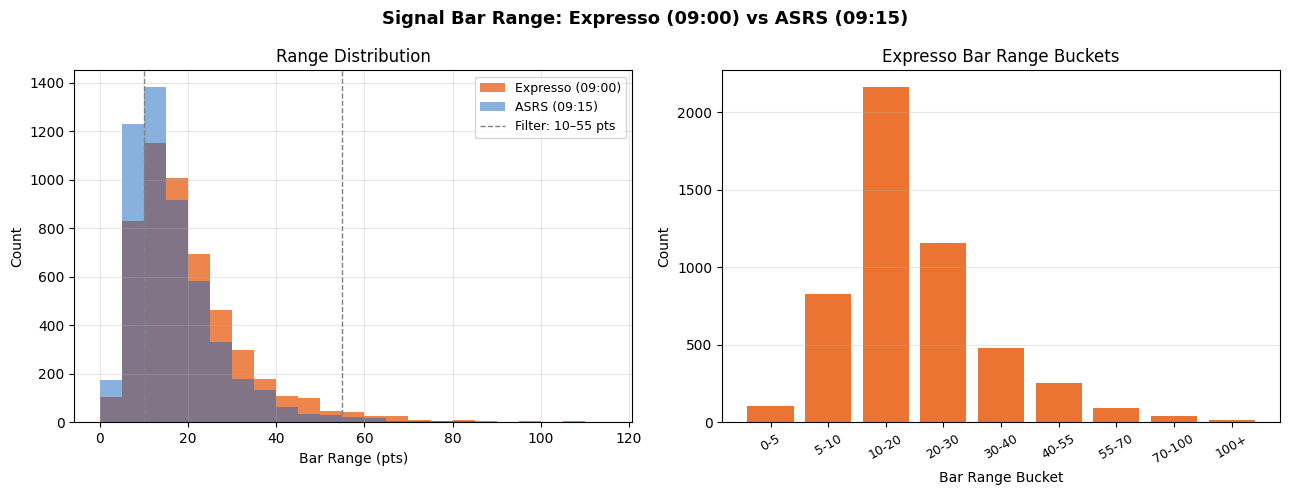

Saved: expresso_range_dist.png


In [5]:
# ── Compare 1st vs 4th bar range distributions ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Signal Bar Range: Expresso (09:00) vs ASRS (09:15)', fontsize=13, fontweight='bold')

bins = np.arange(0, 120, 5)

ax = axes[0]
ax.hist(bars_exp['bar_range'].clip(0, 120),  bins=bins, color='#E65100', alpha=0.7, label='Expresso (09:00)')
ax.hist(bars_asrs['bar_range'].clip(0, 120), bins=bins, color='#1565C0', alpha=0.5, label='ASRS (09:15)')
ax.axvline(RANGE_MIN, color='gray', ls='--', lw=1)
ax.axvline(RANGE_MAX, color='gray', ls='--', lw=1, label=f'Filter: {RANGE_MIN}–{RANGE_MAX} pts')
ax.set_xlabel('Bar Range (pts)')
ax.set_ylabel('Count')
ax.set_title('Range Distribution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
buckets = pd.cut(
    bars_exp['bar_range'],
    bins=[0, 5, 10, 20, 30, 40, 55, 70, 100, 500],
    labels=['0-5','5-10','10-20','20-30','30-40','40-55','55-70','70-100','100+']
).value_counts().sort_index()
ax.bar(buckets.index.astype(str), buckets.values, color='#E65100', alpha=0.8)
ax.set_xlabel('Bar Range Bucket')
ax.set_ylabel('Count')
ax.set_title('Expresso Bar Range Buckets')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_range_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_range_dist.png')

## 4. Backtest Engine

In [6]:
def simulate_day(day_bars: pd.DataFrame, sig_high: float, sig_low: float) -> dict | None:
    """
    Core OCO simulation — shared between Expresso and ASRS.

    day_bars : 5-min bars AFTER signal bar closes (not including signal bar)
    sig_high : signal bar high
    sig_low  : signal bar low

    Returns a dict with trade results, or None if no entry triggered.
    """
    if day_bars.empty:
        return None

    entry_long  = sig_high + ENTRY_BUFFER   # buy-stop
    entry_short = sig_low  - ENTRY_BUFFER   # sell-stop
    stop_long   = entry_short               # long stop = short entry
    stop_short  = entry_long                # short stop = long entry

    direction = entry_price = entry_time = stop = None

    # Phase 1: find first entry
    for ts, bar in day_bars.iterrows():
        if direction is not None:
            break
        bh, bl = bar['high'], bar['low']
        long_hit  = bh >= entry_long
        short_hit = bl <= entry_short

        if long_hit and short_hit:
            if bar['open'] >= entry_long:
                direction, entry_price, stop = 'long',  entry_long,  stop_long
            else:
                direction, entry_price, stop = 'short', entry_short, stop_short
            entry_time = ts
        elif long_hit:
            direction, entry_price, stop, entry_time = 'long',  entry_long,  stop_long,  ts
        elif short_hit:
            direction, entry_price, stop, entry_time = 'short', entry_short, stop_short, ts

    if direction is None:
        return None

    max_adverse = max_favorable = 0.0
    exit_price = exit_time = None
    exit_reason = 'eod'

    # Phase 2: manage trade
    for ts, bar in day_bars[day_bars.index >= entry_time].iterrows():
        bh, bl = bar['high'], bar['low']
        if direction == 'long':
            max_adverse   = max(max_adverse,   entry_price - bl)
            max_favorable = max(max_favorable, bh - entry_price)
            if bl <= stop:
                exit_price, exit_time, exit_reason = stop, ts, 'stop'
                break
        else:
            max_adverse   = max(max_adverse,   bh - entry_price)
            max_favorable = max(max_favorable, entry_price - bl)
            if bh >= stop:
                exit_price, exit_time, exit_reason = stop, ts, 'stop'
                break

    if exit_price is None:
        last = day_bars[day_bars.index >= entry_time].iloc[-1]
        exit_price, exit_time, exit_reason = last['close'], last.name, 'eod'

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)

    return {
        'direction'    : direction,
        'entry_price'  : round(entry_price,  2),
        'entry_time'   : entry_time,
        'exit_price'   : round(exit_price,   2),
        'exit_time'    : exit_time,
        'exit_reason'  : exit_reason,
        'initial_risk' : round(abs(entry_price - stop), 2),
        'pnl'          : round(pnl,           2),
        'max_adverse'  : round(max_adverse,   2),
        'max_favorable': round(max_favorable, 2),
        'sig_high'     : round(sig_high,      2),
        'sig_low'      : round(sig_low,       2),
        'sig_range'    : round(sig_high - sig_low, 2),
    }


print('simulate_day() defined.')

simulate_day() defined.


In [7]:
def run_expresso(
    no_friday:    bool = False,
    range_filter: bool = False,
    skip_months:  bool = False,
) -> pd.DataFrame:
    """Run Expresso backtest (1st bar, 09:00 signal) with optional filters."""
    trades = []
    for trade_date in bars_exp_by_date.index.unique():
        ts_date = pd.Timestamp(trade_date)

        if no_friday   and ts_date.dayofweek in SKIP_DOW:   continue
        if skip_months and ts_date.month    in SKIP_MONTHS: continue

        row = bars_exp_by_date.loc[trade_date]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]

        sig_high  = row['high']
        sig_low   = row['low']
        sig_range = sig_high - sig_low

        if range_filter and not (RANGE_MIN <= sig_range <= RANGE_MAX):
            continue

        day_start = pd.Timestamp(f"{trade_date} {AFTER_SIGNAL_TIME}")
        day_end   = pd.Timestamp(f"{trade_date} {EOD_EXIT_TIME}")
        day_bars  = raw.loc[day_start:day_end]

        if len(day_bars) < 2:
            continue

        result = simulate_day(day_bars, sig_high, sig_low)
        if result is not None:
            result['trade_date'] = ts_date
            trades.append(result)

    return pd.DataFrame(trades).set_index('trade_date').sort_index()


def run_asrs(
    no_friday:    bool = False,
    range_filter: bool = False,
    skip_months:  bool = False,
) -> pd.DataFrame:
    """Run ASRS backtest (4th bar, 09:15 signal) with optional filters."""
    trades = []
    for trade_date in bars_asrs_by_date.index.unique():
        ts_date = pd.Timestamp(trade_date)

        if no_friday   and ts_date.dayofweek in SKIP_DOW:   continue
        if skip_months and ts_date.month    in SKIP_MONTHS: continue

        row = bars_asrs_by_date.loc[trade_date]
        if isinstance(row, pd.DataFrame):
            row = row.iloc[0]

        sig_high  = row['high']
        sig_low   = row['low']
        sig_range = sig_high - sig_low

        if range_filter and not (RANGE_MIN <= sig_range <= RANGE_MAX):
            continue

        day_start = pd.Timestamp(f"{trade_date} {ASRS_AFTER_TIME}")
        day_end   = pd.Timestamp(f"{trade_date} {EOD_EXIT_TIME}")
        day_bars  = raw.loc[day_start:day_end]

        if len(day_bars) < 2:
            continue

        result = simulate_day(day_bars, sig_high, sig_low)
        if result is not None:
            result['trade_date'] = ts_date
            trades.append(result)

    return pd.DataFrame(trades).set_index('trade_date').sort_index()


print('run_expresso() and run_asrs() defined. Running all variants...')

results = {
    'EXP_raw'     : run_expresso(no_friday=False, range_filter=False, skip_months=False),
    'EXP_range'   : run_expresso(no_friday=False, range_filter=True,  skip_months=False),
    'EXP_no_fri'  : run_expresso(no_friday=True,  range_filter=False, skip_months=False),
    'EXP_months'  : run_expresso(no_friday=False, range_filter=False, skip_months=True),
    'EXP_best'    : run_expresso(no_friday=True,  range_filter=True,  skip_months=True),
    'ASRS_best'   : run_asrs   (no_friday=True,  range_filter=True,  skip_months=True),
}

for k, df in results.items():
    print(f'  {k:<14}: {len(df):,} trades')

run_expresso() and run_asrs() defined. Running all variants...


  EXP_raw       : 5,135 trades
  EXP_range     : 4,050 trades
  EXP_no_fri    : 4,120 trades
  EXP_months    : 3,800 trades
  EXP_best      : 2,371 trades
  ASRS_best     : 2,134 trades


## 5. Performance Metrics

In [8]:
def metrics(df: pd.DataFrame, label: str = '') -> dict:
    if df.empty:
        return {'label': label, 'n_trades': 0}

    winners = df[df['pnl'] > 0]
    losers  = df[df['pnl'] < 0]
    n_w, n_l = len(winners), len(losers)

    avg_win  = winners['pnl'].mean() if n_w else 0.0
    avg_loss = losers ['pnl'].mean() if n_l else 0.0

    gw = winners['pnl'].sum() if n_w else 0.0
    gl = abs(losers['pnl'].sum()) if n_l else 1e-9
    pf = gw / gl

    std = df['pnl'].std()
    sharpe = (df['pnl'].mean() / std * np.sqrt(252)) if std > 0 else 0.0

    cum = df['pnl'].cumsum()
    max_dd = (cum - cum.cummax()).min()

    longs  = df[df['direction'] == 'long']
    shorts = df[df['direction'] == 'short']

    n_stop = (df['exit_reason'] == 'stop').sum()
    n_eod  = (df['exit_reason'] == 'eod' ).sum()

    return {
        'label'         : label,
        'n_trades'      : len(df),
        'win_rate_%'    : round((df['pnl'] > 0).mean() * 100, 1),
        'avg_win_pts'   : round(avg_win,  1),
        'avg_loss_pts'  : round(avg_loss, 1),
        'wl_ratio'      : round(abs(avg_win / avg_loss), 2) if avg_loss != 0 else np.inf,
        'profit_factor' : round(pf, 2),
        'total_pnl'     : round(df['pnl'].sum(), 0),
        'avg_trade_pts' : round(df['pnl'].mean(), 2),
        'sharpe'        : round(sharpe, 2),
        'max_dd'        : round(max_dd, 0),
        'wr_long_%'     : round((longs ['pnl'] > 0).mean() * 100, 1) if len(longs)  else 0.0,
        'wr_short_%'    : round((shorts['pnl'] > 0).mean() * 100, 1) if len(shorts) else 0.0,
        'n_stop'        : int(n_stop),
        'n_eod'         : int(n_eod),
    }


rows = [metrics(df, label=k) for k, df in results.items()]
summary = pd.DataFrame(rows).set_index('label')

COLS = ['n_trades', 'win_rate_%', 'avg_win_pts', 'avg_loss_pts',
        'wl_ratio', 'profit_factor', 'total_pnl', 'avg_trade_pts', 'sharpe', 'max_dd']

print('=== Expresso Backtest — Performance Summary ===')
print(summary[COLS].to_string())

=== Expresso Backtest — Performance Summary ===
            n_trades  win_rate_%  avg_win_pts  avg_loss_pts  wl_ratio  profit_factor  total_pnl  avg_trade_pts  sharpe  max_dd
label                                                                                                                         
EXP_raw         5135        31.0         55.4         -23.2      2.39           1.07     5816.0           1.13    0.37 -1923.0
EXP_range       4050        31.5         58.3         -24.4      2.38           1.10     6650.0           1.64    0.52 -1718.0
EXP_no_fri      4120        31.4         56.0         -22.9      2.45           1.12     7907.0           1.92    0.62 -1763.0
EXP_months      3800        30.7         56.9         -23.4      2.43           1.08     4807.0           1.26    0.40 -1822.0
EXP_best        2371        32.3         61.2         -24.5      2.50           1.19     7601.0           3.21    0.97 -1113.0
ASRS_best       2134        30.2         67.2         -22.9    

In [9]:
# ── Improvement vs EXP_raw ────────────────────────────────────────────────────
base = summary.loc['EXP_raw']
print('=== Filter Improvement vs EXP_raw (no filters) ===')
print(f'{"Variant":<14}  {"N":>6}  {"PnL Δ":>9}  {"PF Δ":>7}  {"Sharpe Δ":>9}  {"MaxDD Δ":>9}')
print('-' * 62)
for label, row in summary.iterrows():
    if label == 'EXP_raw':
        print(f'{label:<14}  {int(row["n_trades"]):>6,}  '
              f'{row["total_pnl"]:>+9,.0f}  '
              f'{row["profit_factor"]:>7.2f}  '
              f'{row["sharpe"]:>9.2f}  '
              f'{row["max_dd"]:>+9,.0f}  ← baseline')
    else:
        pnl_d    = row['total_pnl']     - base['total_pnl']
        pf_d     = row['profit_factor'] - base['profit_factor']
        sharpe_d = row['sharpe']        - base['sharpe']
        dd_d     = row['max_dd']        - base['max_dd']
        print(f'{label:<14}  {int(row["n_trades"]):>6,}  '
              f'{pnl_d:>+9,.0f}  '
              f'{pf_d:>+7.2f}  '
              f'{sharpe_d:>+9.2f}  '
              f'{dd_d:>+9,.0f}')

=== Filter Improvement vs EXP_raw (no filters) ===
Variant              N      PnL Δ     PF Δ   Sharpe Δ    MaxDD Δ
--------------------------------------------------------------
EXP_raw          5,135     +5,816     1.07       0.37     -1,923  ← baseline
EXP_range        4,050       +834    +0.03      +0.15       +205
EXP_no_fri       4,120     +2,091    +0.05      +0.25       +160
EXP_months       3,800     -1,009    +0.01      +0.03       +101
EXP_best         2,371     +1,785    +0.12      +0.60       +810
ASRS_best        2,134     +3,462    +0.20      +0.86       +811


## 6. Signal Bar Range Analysis (Expresso)

Does the range of the 1st bar predict anything about outcome?

=== Expresso: Signal Bar Range vs Performance ===
  Bucket       N      WR%     AvgPnL     TotalPnL
------------------------------------------------
     0-5     106    28.3%       +2.0         +218
    5-10     830    27.7%       +0.5         +414
   10-15   1,154    27.9%       +0.4         +470 ← F2
   15-20   1,009    34.3%       +4.7        +4758 ← F2
   20-30   1,156    32.4%       +0.8         +887 ← F2
   30-40     478    28.9%       -1.2         -585 ← F2
   40-55     253    37.9%       +4.4        +1120 ← F2
   55-70      92    40.2%       +1.0          +93
  70-100      41    29.3%      -15.3         -628
    100+      16    25.0%      -58.2         -931


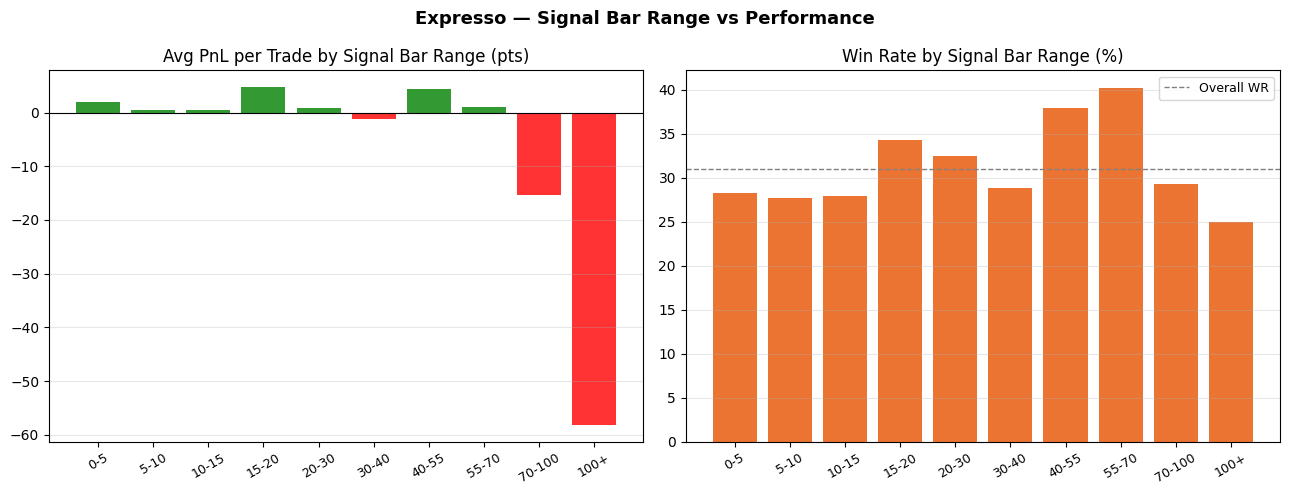

Saved: expresso_range_perf.png


In [10]:
df_exp = results['EXP_raw'].copy()

df_exp['range_bucket'] = pd.cut(
    df_exp['sig_range'],
    bins=[0, 5, 10, 15, 20, 30, 40, 55, 70, 100, 500],
    labels=['0-5','5-10','10-15','15-20','20-30','30-40','40-55','55-70','70-100','100+']
)

range_perf = df_exp.groupby('range_bucket', observed=True).agg(
    n         = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl   = ('pnl', 'mean'),
).round(2)

print('=== Expresso: Signal Bar Range vs Performance ===')
print(f'{"Bucket":>8}  {"N":>6}  {"WR%":>7}  {"AvgPnL":>9}  {"TotalPnL":>11}')
print('-' * 48)
for bucket, row in range_perf.iterrows():
    flag = ' ← F2' if str(bucket) in ['10-15','15-20','20-30','30-40','40-55'] else ''
    print(f'{str(bucket):>8}  {int(row["n"]):>6,}  {row["win_rate"]:>6.1f}%  '
          f'{row["avg_pnl"]:>+9.1f}  {row["total_pnl"]:>+11.0f}{flag}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Expresso — Signal Bar Range vs Performance', fontsize=13, fontweight='bold')

xlabels = [str(b) for b in range_perf.index]
xpos = range(len(xlabels))

ax = axes[0]
colors = ['green' if v > 0 else 'red' for v in range_perf['avg_pnl']]
ax.bar(xpos, range_perf['avg_pnl'], color=colors, alpha=0.8)
ax.set_xticks(xpos)
ax.set_xticklabels(xlabels, rotation=30, fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Avg PnL per Trade by Signal Bar Range (pts)')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
ax.bar(xpos, range_perf['win_rate'], color='#E65100', alpha=0.8)
ax.set_xticks(xpos)
ax.set_xticklabels(xlabels, rotation=30, fontsize=9)
ax.axhline(df_exp['pnl'].gt(0).mean() * 100, color='gray', ls='--', lw=1, label='Overall WR')
ax.set_title('Win Rate by Signal Bar Range (%)')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_range_perf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_range_perf.png')

## 7. Day-of-Week & Monthly Seasonality

In [11]:
dow_map   = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri'}
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

df_raw = results['EXP_raw'].copy()
df_raw['dow']   = df_raw.index.dayofweek
df_raw['month'] = df_raw.index.month

# Day-of-week
dow_perf = df_raw.groupby('dow').agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl   = ('pnl', 'mean'),
).round(1)
dow_perf.index = [dow_map.get(i, i) for i in dow_perf.index]

print('=== Expresso: Day-of-Week Performance ===')
print(dow_perf.to_string())

# Monthly
month_perf = df_raw.groupby('month').agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl   = ('pnl', 'mean'),
).round(1)
month_perf.index = [month_map[i] for i in month_perf.index]

print('\n=== Expresso: Monthly Performance ===')
print(month_perf.to_string())

weak_months_exp   = month_perf[month_perf['avg_pnl'] < 0].index.tolist()
strong_months_exp = month_perf[month_perf['avg_pnl'] > 3].index.tolist()
print(f'\nWeak months (avg < 0)   : {weak_months_exp}')
print(f'Strong months (avg > 3) : {strong_months_exp}')

=== Expresso: Day-of-Week Performance ===
     trades  total_pnl  win_rate  avg_pnl
Mon    1010      615.1      31.5      0.6
Tue    1036     3272.4      34.1      3.2
Wed    1037     -753.1      27.8     -0.7
Thu    1037     4772.9      32.4      4.6
Fri    1015    -2091.8      29.1     -2.1

=== Expresso: Monthly Performance ===
     trades  total_pnl  win_rate  avg_pnl
Jan     451      783.7      31.5      1.7
Feb     424      629.2      29.5      1.5
Mar     457      238.2      27.8      0.5
Apr     397     1327.0      34.3      3.3
May     425     -100.4      31.8     -0.2
Jun     426     3149.4      37.3      7.4
Jul     443     -353.8      29.8     -0.8
Aug     441      578.7      33.6      1.3
Sep     427       63.3      29.0      0.1
Oct     439       18.0      31.2      0.0
Nov     428     -855.3      25.5     -2.0
Dec     377      337.4      30.8      0.9

Weak months (avg < 0)   : ['May', 'Jul', 'Nov']
Strong months (avg > 3) : ['Apr', 'Jun']


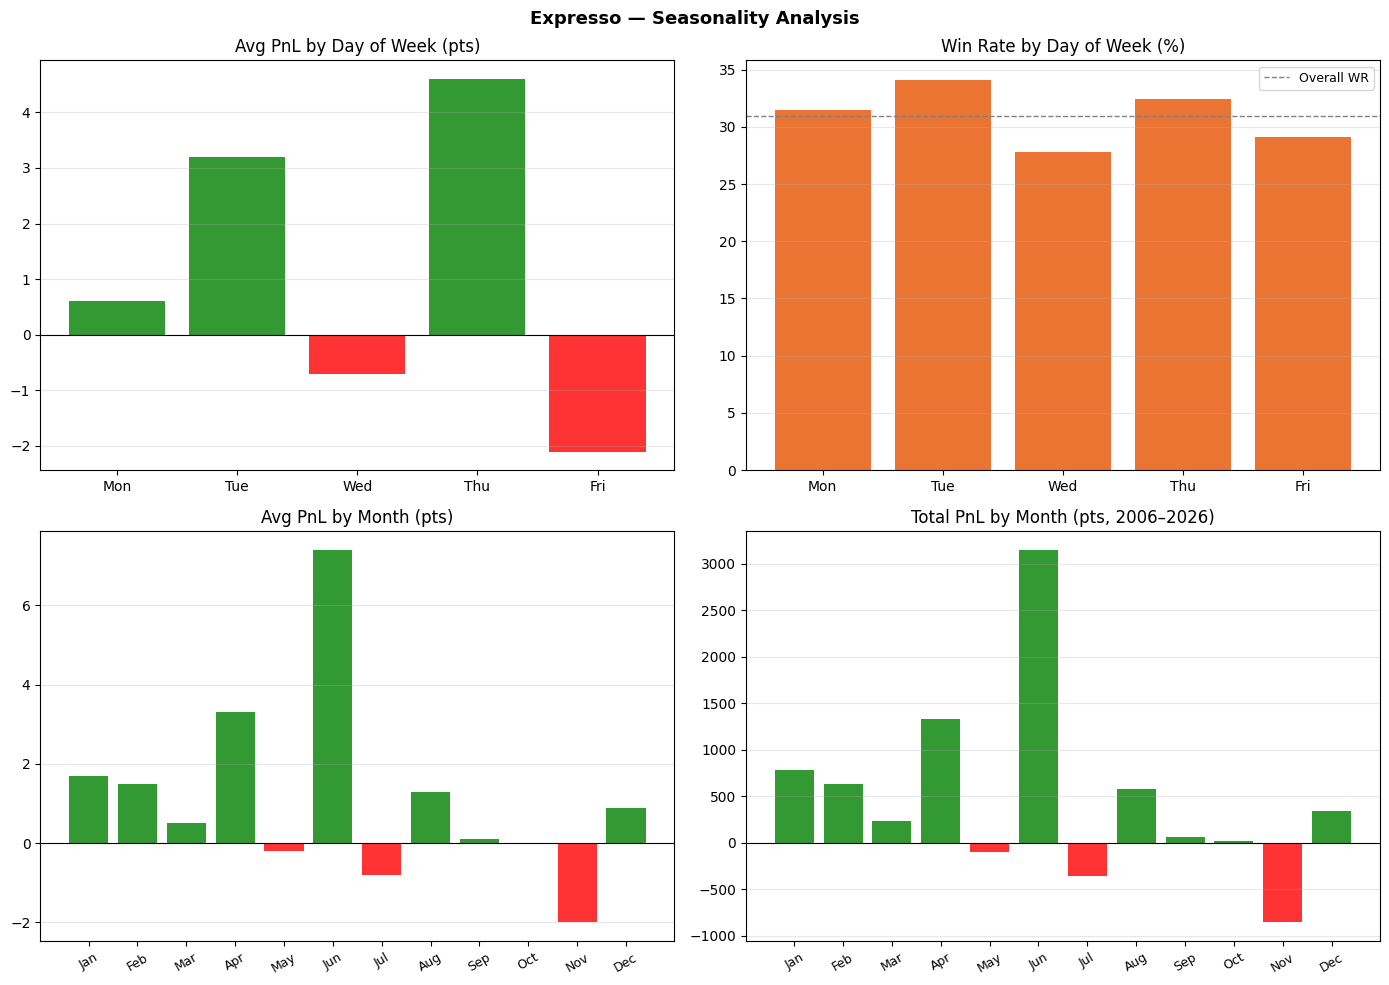

Saved: expresso_seasonality.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Expresso — Seasonality Analysis', fontsize=13, fontweight='bold')

# DOW: avg PnL
ax = axes[0, 0]
c = ['green' if v > 0 else 'red' for v in dow_perf['avg_pnl']]
ax.bar(dow_perf.index, dow_perf['avg_pnl'], color=c, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Avg PnL by Day of Week (pts)')
ax.grid(True, axis='y', alpha=0.3)

# DOW: win rate
ax = axes[0, 1]
ax.bar(dow_perf.index, dow_perf['win_rate'], color='#E65100', alpha=0.8)
ax.axhline(df_raw['pnl'].gt(0).mean() * 100, color='gray', ls='--', lw=1, label='Overall WR')
ax.set_title('Win Rate by Day of Week (%)')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

# Monthly: avg PnL
ax = axes[1, 0]
c2 = ['green' if v > 0 else 'red' for v in month_perf['avg_pnl']]
ax.bar(month_perf.index, month_perf['avg_pnl'], color=c2, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Avg PnL by Month (pts)')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.grid(True, axis='y', alpha=0.3)

# Monthly: total PnL
ax = axes[1, 1]
c3 = ['green' if v > 0 else 'red' for v in month_perf['total_pnl']]
ax.bar(month_perf.index, month_perf['total_pnl'], color=c3, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Total PnL by Month (pts, 2006–2026)')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_seasonality.png')

## 8. Annual Performance

In [13]:
def annual_pnl(df: pd.DataFrame) -> pd.Series:
    return df.groupby(df.index.year)['pnl'].sum().round(1)

ann = pd.DataFrame({
    k: annual_pnl(df) for k, df in results.items()
})

print('=== Annual PnL by Variant ===')
print(ann.to_string())

# Years where EXP_best beats ASRS_best
ann_cmp = ann[['EXP_best', 'ASRS_best']].dropna()
wins_exp  = (ann_cmp['EXP_best'] > ann_cmp['ASRS_best']).sum()
print(f'\nEXP_best beats ASRS_best in {wins_exp}/{len(ann_cmp)} years')

=== Annual PnL by Variant ===
            EXP_raw  EXP_range  EXP_no_fri  EXP_months  EXP_best  ASRS_best
trade_date                                                                 
2006           35.3     -132.8       157.1        52.5      14.1     -159.3
2007          394.1      -14.6       645.0       459.9     111.9     -410.0
2008         1826.5     1769.7      2180.5      1149.5    1640.2     1414.6
2009         -719.9     -711.2       -92.7      -328.8      39.0     -141.1
2010         -497.0     -492.1      -164.9      -463.6    -210.4      -46.3
2011          349.3      918.2       891.0      -194.5     466.8        2.6
2012         -539.9     -395.5      -502.5      -453.0    -292.9     -236.3
2013          333.6      730.2       280.3       442.3     436.1      466.9
2014         1657.1     1510.2      1640.1      1418.0    1307.3      577.6
2015         -839.0    -1110.8      -499.9      -883.3    -594.9       28.4
2016          460.4      564.8       761.7       161.1    

## 9. Equity Curves — All Variants

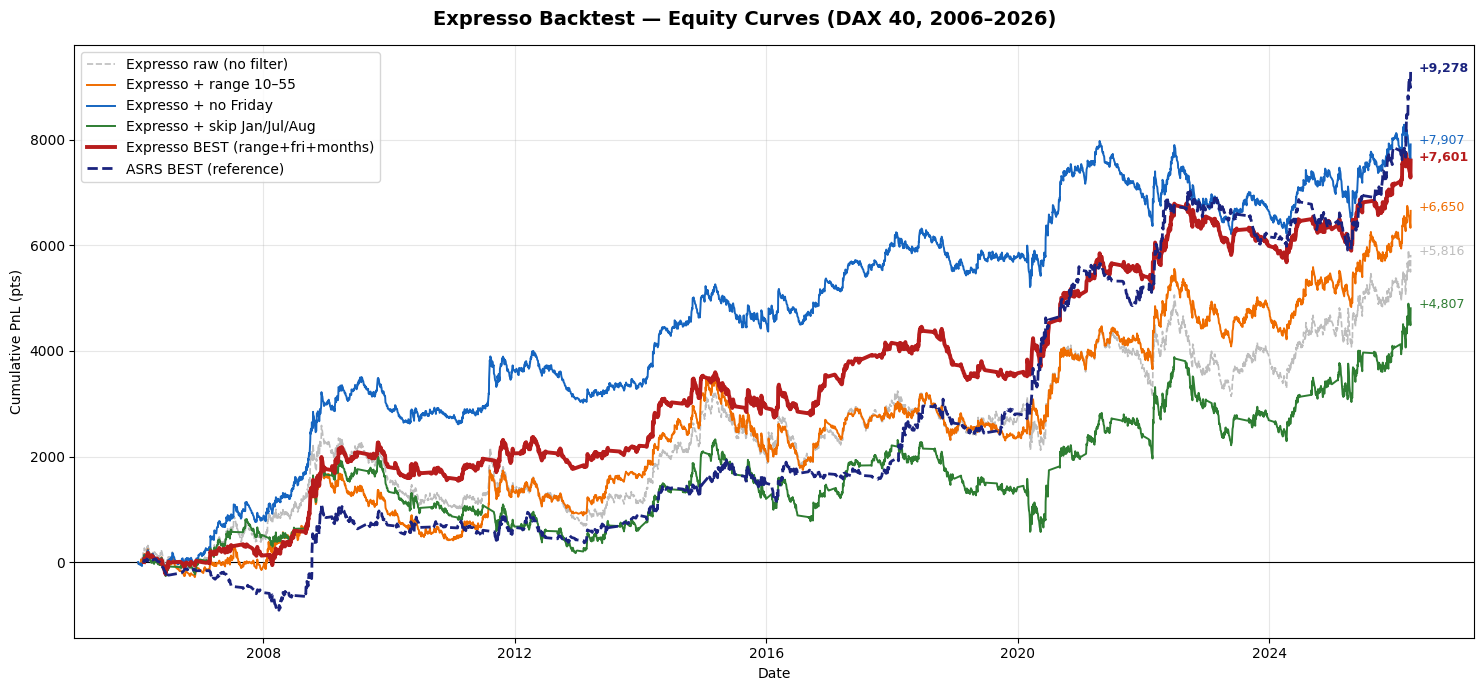

Saved: expresso_equity.png


In [14]:
palette = {
    'EXP_raw'    : ('#BDBDBD', '--', 1.2, 'Expresso raw (no filter)'),
    'EXP_range'  : ('#EF6C00', '-',  1.4, 'Expresso + range 10–55'),
    'EXP_no_fri' : ('#1565C0', '-',  1.4, 'Expresso + no Friday'),
    'EXP_months' : ('#2E7D32', '-',  1.4, 'Expresso + skip Jan/Jul/Aug'),
    'EXP_best'   : ('#B71C1C', '-',  2.8, 'Expresso BEST (range+fri+months)'),
    'ASRS_best'  : ('#1A237E', '--', 2.0, 'ASRS BEST (reference)'),
}

fig, ax = plt.subplots(figsize=(15, 7))
fig.suptitle('Expresso Backtest — Equity Curves (DAX 40, 2006–2026)', fontsize=14, fontweight='bold')

for key, (color, ls, lw, label) in palette.items():
    if key not in results:
        continue
    df_v = results[key]
    cum  = df_v['pnl'].cumsum()
    ax.plot(cum.index, cum.values, color=color, lw=lw, ls=ls, label=label,
            zorder=5 if key in ('EXP_best', 'ASRS_best') else 3)
    final = cum.iloc[-1]
    ax.annotate(
        f'{final:+,.0f}',
        xy=(cum.index[-1], final),
        xytext=(6, 0), textcoords='offset points',
        color=color, fontsize=9,
        fontweight='bold' if key in ('EXP_best', 'ASRS_best') else 'normal'
    )

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Cumulative PnL (pts)')
ax.set_xlabel('Date')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_equity.png')

## 10. Head-to-Head: Expresso BEST vs ASRS BEST

In [15]:
m_exp  = metrics(results['EXP_best'],  label='EXP_best')
m_asrs = metrics(results['ASRS_best'], label='ASRS_best')

print('=== Head-to-Head: Expresso BEST vs ASRS BEST ===')
print(f'{"Metric":<22}  {"Expresso":>12}  {"ASRS":>12}  {"Delta":>10}')
print('-' * 62)

metric_rows = [
    ('n_trades',       'Trades'),
    ('win_rate_%',     'Win rate %'),
    ('avg_win_pts',    'Avg win pts'),
    ('avg_loss_pts',   'Avg loss pts'),
    ('wl_ratio',       'Win/Loss ratio'),
    ('profit_factor',  'Profit factor'),
    ('total_pnl',      'Total PnL'),
    ('avg_trade_pts',  'Avg trade pts'),
    ('sharpe',         'Sharpe'),
    ('max_dd',         'Max drawdown'),
    ('wr_long_%',      'WR long %'),
    ('wr_short_%',     'WR short %'),
    ('n_stop',         'Stop-outs'),
    ('n_eod',          'EOD exits'),
]

for key, label in metric_rows:
    e = m_exp.get(key, 0)
    a = m_asrs.get(key, 0)
    if isinstance(e, float) or isinstance(a, float):
        chg = f'{e-a:+.2f}'
        e_s = f'{e:.2f}'
        a_s = f'{a:.2f}'
    else:
        chg = f'{e-a:+,}'
        e_s = f'{e:,}'
        a_s = f'{a:,}'
    print(f'{label:<22}  {e_s:>12}  {a_s:>12}  {chg:>10}')

=== Head-to-Head: Expresso BEST vs ASRS BEST ===
Metric                      Expresso          ASRS       Delta
--------------------------------------------------------------
Trades                         2,371         2,134        +237
Win rate %                     32.30         30.20       +2.10
Avg win pts                    61.20         67.20       -6.00
Avg loss pts                  -24.50        -22.90       -1.60
Win/Loss ratio                  2.50          2.94       -0.44
Profit factor                   1.19          1.27       -0.08
Total PnL                    7601.00       9278.00    -1677.00
Avg trade pts                   3.21          4.35       -1.14
Sharpe                          0.97          1.23       -0.26
Max drawdown                -1113.00      -1112.00       -1.00
WR long %                      36.90         33.80       +3.10
WR short %                     27.70         26.60       +1.10
Stop-outs                      1,506         1,418         +88
EOD ex

In [16]:
# Annual PnL: Expresso BEST vs ASRS BEST with improvement
ann_exp  = annual_pnl(results['EXP_best'])
ann_asrs = annual_pnl(results['ASRS_best'])
ann_h2h  = pd.DataFrame({'EXP_best': ann_exp, 'ASRS_best': ann_asrs}).fillna(0)
ann_h2h['exp_minus_asrs'] = (ann_h2h['EXP_best'] - ann_h2h['ASRS_best']).round(1)

print('=== Annual PnL — Expresso BEST vs ASRS BEST ===')
print(f'{"Year":<6}  {"EXP_best":>10}  {"ASRS_best":>11}  {"Exp-ASRS":>10}')
print('-' * 44)
for yr, row in ann_h2h.iterrows():
    marker = ' ✓' if row['exp_minus_asrs'] > 0 else ' ✗'
    print(f'{yr:<6}  {row["EXP_best"]:>+10.0f}  {row["ASRS_best"]:>+11.0f}  '
          f'{row["exp_minus_asrs"]:>+10.0f}{marker}')

wins = (ann_h2h['exp_minus_asrs'] > 0).sum()
print(f'\nExpresso beats ASRS in {wins}/{len(ann_h2h)} years')

=== Annual PnL — Expresso BEST vs ASRS BEST ===
Year      EXP_best    ASRS_best    Exp-ASRS
--------------------------------------------
2006           +14         -159        +173 ✓
2007          +112         -410        +522 ✓
2008         +1640        +1415        +226 ✓
2009           +39         -141        +180 ✓
2010          -210          -46        -164 ✗
2011          +467           +3        +464 ✓
2012          -293         -236         -57 ✗
2013          +436         +467         -31 ✗
2014         +1307         +578        +730 ✓
2015          -595          +28        -623 ✗
2016          +595         +180        +415 ✓
2017          +641         +237        +404 ✓
2018          -413         +717       -1130 ✗
2019          -163         +178        -341 ✗
2020         +1491        +2722       -1231 ✗
2021          +346         -319        +665 ✓
2022         +1130        +1528        -398 ✗
2023          -556         -581         +25 ✓
2024          +312         +214    

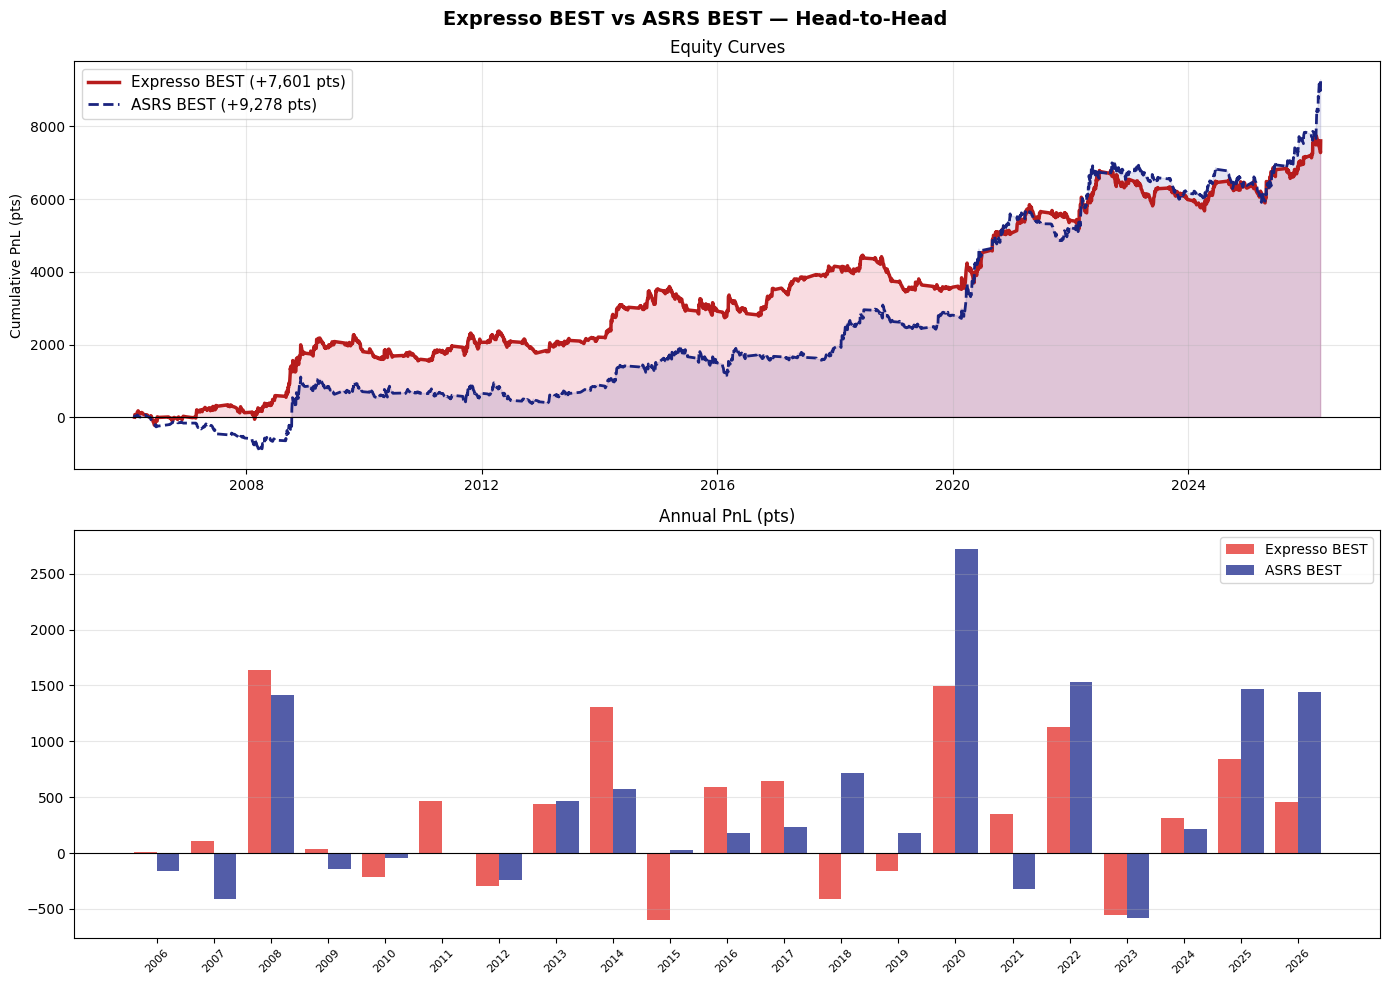

Saved: expresso_h2h.png


In [17]:
# Visual head-to-head
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Expresso BEST vs ASRS BEST — Head-to-Head', fontsize=14, fontweight='bold')

# Top: equity curves
ax = axes[0]
cum_exp  = results['EXP_best']['pnl'].cumsum()
cum_asrs = results['ASRS_best']['pnl'].cumsum()

ax.fill_between(cum_exp.index,  cum_exp.values,  0,
                where=cum_exp.values >= 0,  alpha=0.15, color='crimson')
ax.fill_between(cum_asrs.index, cum_asrs.values, 0,
                where=cum_asrs.values >= 0, alpha=0.10, color='navy')

ax.plot(cum_exp.index,  cum_exp.values,  color='#B71C1C', lw=2.5, label=f'Expresso BEST ({cum_exp.iloc[-1]:+,.0f} pts)')
ax.plot(cum_asrs.index, cum_asrs.values, color='#1A237E', lw=2.0, ls='--', label=f'ASRS BEST ({cum_asrs.iloc[-1]:+,.0f} pts)')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Cumulative PnL (pts)')
ax.set_title('Equity Curves')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Bottom: annual bar chart
ax2 = axes[1]
years_str = ann_h2h.index.astype(str)
x2 = np.arange(len(years_str))
w2 = 0.40
ax2.bar(x2 - w2/2, ann_h2h['EXP_best'],   w2, color='#E53935', alpha=0.8, label='Expresso BEST')
ax2.bar(x2 + w2/2, ann_h2h['ASRS_best'],  w2, color='#283593', alpha=0.8, label='ASRS BEST')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x2)
ax2.set_xticklabels(years_str, rotation=45, fontsize=8)
ax2.set_title('Annual PnL (pts)')
ax2.legend(fontsize=10)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_h2h.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_h2h.png')

## 11. Entry Timing: How Long After Signal Does the Trade Trigger?

The Expresso enters from 09:05 onwards — we have more of the trading day
ahead of us compared to ASRS (which enters from 09:20). Does this translate
into larger average wins?

In [18]:
# Compute minutes from session open (09:00) to entry
def entry_minutes_from_open(df: pd.DataFrame, open_time_str: str = '09:05') -> pd.Series:
    """Minutes from after_signal time to actual entry bar."""
    open_ref = df['entry_time'].dt.hour * 60 + df['entry_time'].dt.minute
    h, m = map(int, open_time_str.split(':'))
    ref_mins = h * 60 + m
    return (open_ref - ref_mins).clip(lower=0)


df_exp_best  = results['EXP_best'].copy()
df_asrs_best = results['ASRS_best'].copy()

df_exp_best['entry_mins']  = entry_minutes_from_open(df_exp_best,  '09:05')
df_asrs_best['entry_mins'] = entry_minutes_from_open(df_asrs_best, '09:20')

print('=== Time-to-Entry Distribution (minutes after signal bar close) ===')
print(f'\nExpresso (entry from 09:05):');
print(df_exp_best['entry_mins'].describe().round(1))
print(f'\nASRS (entry from 09:20):');
print(df_asrs_best['entry_mins'].describe().round(1))

# PnL vs time-to-entry
df_exp_best['entry_bucket'] = pd.cut(
    df_exp_best['entry_mins'],
    bins=[-1, 0, 5, 15, 30, 60, 999],
    labels=['0', '1-5', '6-15', '16-30', '31-60', '60+']
)

entry_perf = df_exp_best.groupby('entry_bucket', observed=True).agg(
    n        = ('pnl', 'count'),
    avg_pnl  = ('pnl', 'mean'),
    win_rate = ('pnl', lambda x: (x > 0).mean() * 100),
).round(1)

print('\n=== Expresso: PnL by Time-to-Entry (mins after 09:05) ===')
print(entry_perf.to_string())

=== Time-to-Entry Distribution (minutes after signal bar close) ===

Expresso (entry from 09:05):
count    2371.0
mean        3.6
std        10.8
min         0.0
25%         0.0
50%         0.0
75%         5.0
max       325.0
Name: entry_mins, dtype: float64

ASRS (entry from 09:20):
count    2134.0
mean        2.8
std         6.4
min         0.0
25%         0.0
50%         0.0
75%         5.0
max       100.0
Name: entry_mins, dtype: float64

=== Expresso: PnL by Time-to-Entry (mins after 09:05) ===
                 n  avg_pnl  win_rate
entry_bucket                         
0             1621      2.5      29.5
1-5            416      4.8      36.3
6-15           229      4.4      37.1
16-30           66      7.9      51.5
31-60           29      3.2      48.3
60+             10    -10.8      40.0


## 12. Excursion Analysis

--- Expresso BEST ---
  Winners (766):
    Avg max adverse   : 14.9 pts
    Avg max favorable : 88.6 pts
    Avg PnL           : 61.2 pts
  Losers (1,605):
    Avg max adverse   : 31.0 pts
    Avg max favorable : 20.9 pts
  Exits — stop: 1,506 (63.5%)  EOD: 865 (36.5%)
  Avg PnL on EOD exits  : 53.0 pts
  Avg PnL on stop exits : -25.4 pts

--- ASRS BEST ---
  Winners (645):
    Avg max adverse   : 13.8 pts
    Avg max favorable : 95.2 pts
    Avg PnL           : 67.2 pts
  Losers (1,489):
    Avg max adverse   : 29.7 pts
    Avg max favorable : 20.4 pts
  Exits — stop: 1,418 (66.4%)  EOD: 716 (33.6%)
  Avg PnL on EOD exits  : 59.7 pts
  Avg PnL on stop exits : -23.6 pts



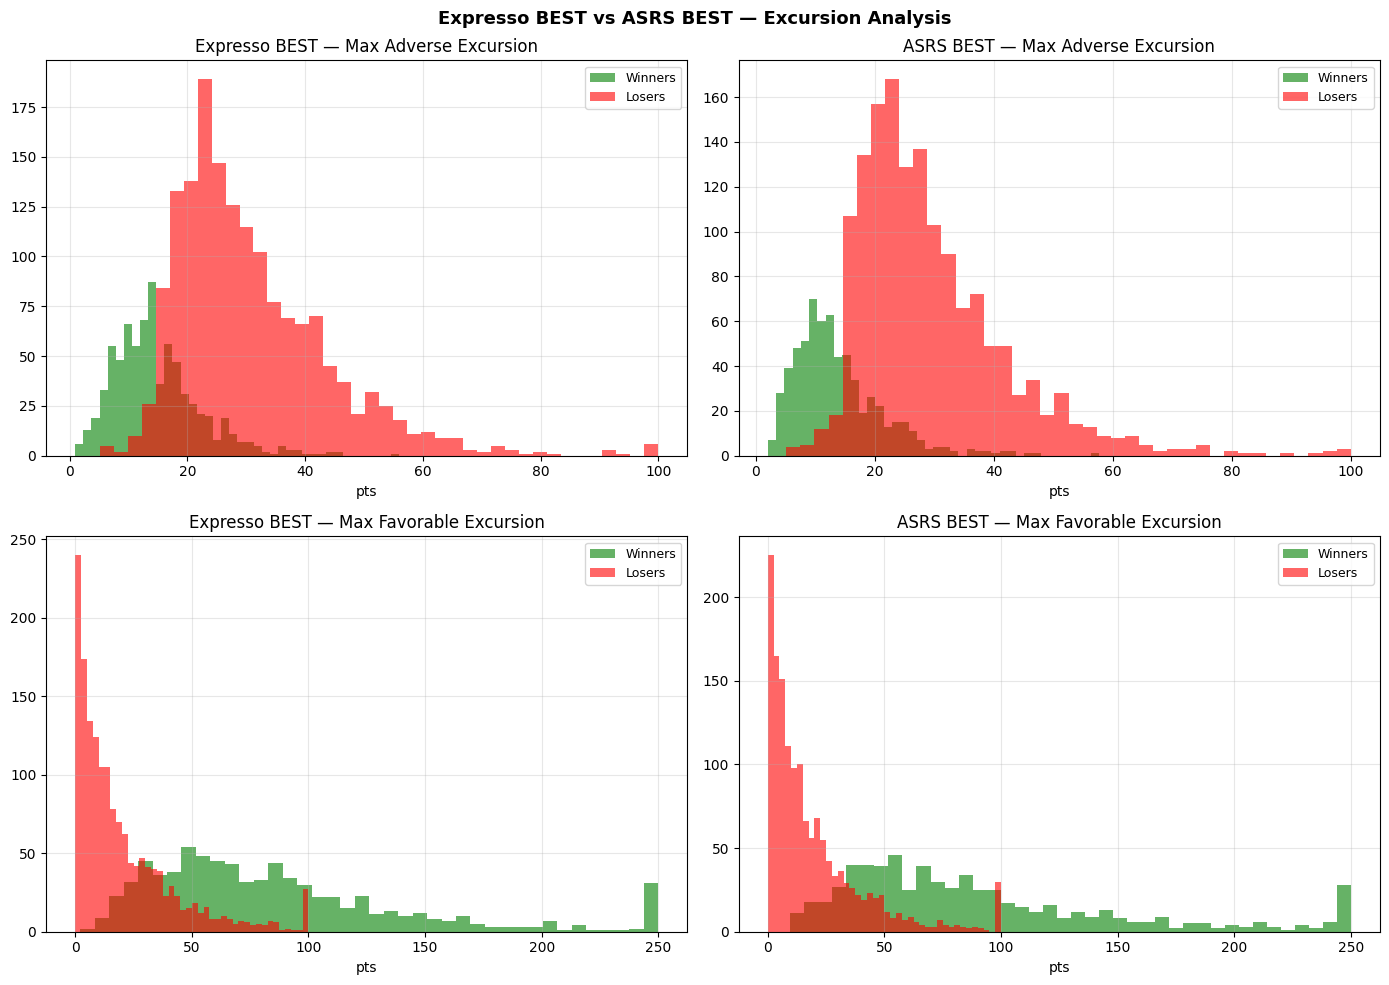

Saved: expresso_excursion.png


In [19]:
for label, df_v in [('Expresso BEST', df_exp_best), ('ASRS BEST', df_asrs_best)]:
    winners = df_v[df_v['pnl'] > 0]
    losers  = df_v[df_v['pnl'] < 0]
    print(f'--- {label} ---')
    print(f'  Winners ({len(winners):,}):')
    print(f'    Avg max adverse   : {winners["max_adverse"].mean():.1f} pts')
    print(f'    Avg max favorable : {winners["max_favorable"].mean():.1f} pts')
    print(f'    Avg PnL           : {winners["pnl"].mean():.1f} pts')
    print(f'  Losers ({len(losers):,}):')
    print(f'    Avg max adverse   : {losers["max_adverse"].mean():.1f} pts')
    print(f'    Avg max favorable : {losers["max_favorable"].mean():.1f} pts')
    n_stop = (df_v['exit_reason'] == 'stop').sum()
    n_eod  = (df_v['exit_reason'] == 'eod').sum()
    print(f'  Exits — stop: {n_stop:,} ({n_stop/len(df_v)*100:.1f}%)  EOD: {n_eod:,} ({n_eod/len(df_v)*100:.1f}%)')
    print(f'  Avg PnL on EOD exits  : {df_v[df_v["exit_reason"]=="eod"]["pnl"].mean():.1f} pts')
    print(f'  Avg PnL on stop exits : {df_v[df_v["exit_reason"]=="stop"]["pnl"].mean():.1f} pts')
    print()

# Visual excursion comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Expresso BEST vs ASRS BEST — Excursion Analysis', fontsize=13, fontweight='bold')

for col_idx, (label, df_v) in enumerate([('Expresso BEST', df_exp_best), ('ASRS BEST', df_asrs_best)]):
    winners_v = df_v[df_v['pnl'] > 0]
    losers_v  = df_v[df_v['pnl'] < 0]

    ax = axes[0, col_idx]
    ax.hist(winners_v['max_adverse'].clip(0, 100), bins=40, color='green', alpha=0.6, label='Winners')
    ax.hist(losers_v ['max_adverse'].clip(0, 100), bins=40, color='red',   alpha=0.6, label='Losers')
    ax.set_title(f'{label} — Max Adverse Excursion')
    ax.set_xlabel('pts')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[1, col_idx]
    ax.hist(winners_v['max_favorable'].clip(0, 250), bins=40, color='green', alpha=0.6, label='Winners')
    ax.hist(losers_v ['max_favorable'].clip(0, 100), bins=40, color='red',   alpha=0.6, label='Losers')
    ax.set_title(f'{label} — Max Favorable Excursion')
    ax.set_xlabel('pts')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'expresso_excursion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_excursion.png')

## 13. Summary Dashboard

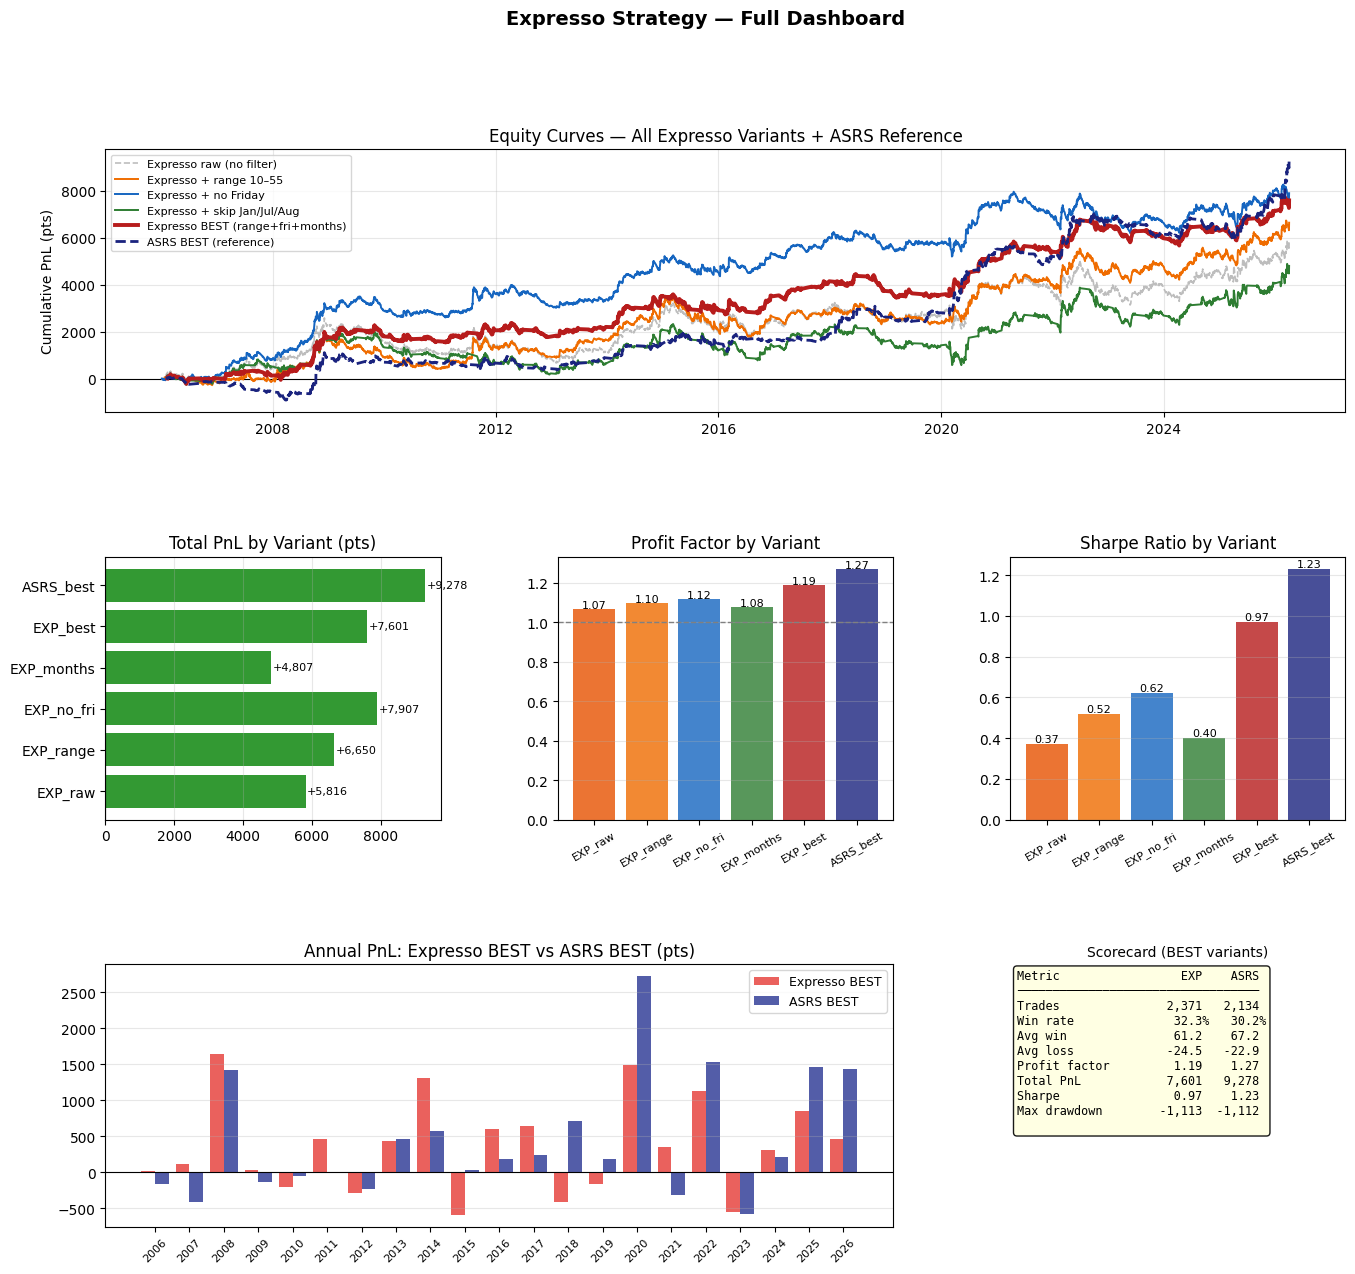

Saved: expresso_dashboard.png


In [20]:
fig = plt.figure(figsize=(16, 14))
fig.suptitle('Expresso Strategy — Full Dashboard', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# 1. Main equity curve: best variants
ax1 = fig.add_subplot(gs[0, :])
for key, (color, ls, lw, label) in palette.items():
    if key not in results:
        continue
    cum = results[key]['pnl'].cumsum()
    ax1.plot(cum.index, cum.values, color=color, lw=lw, ls=ls, label=label,
             zorder=5 if key in ('EXP_best', 'ASRS_best') else 3)
ax1.axhline(0, color='black', lw=0.8)
ax1.set_title('Equity Curves — All Expresso Variants + ASRS Reference')
ax1.set_ylabel('Cumulative PnL (pts)')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. PnL by variant bar
ax2 = fig.add_subplot(gs[1, 0])
keys_order = list(results.keys())
pnl_vals = [results[k]['pnl'].sum() for k in keys_order]
pf_vals  = [metrics(results[k])['profit_factor'] for k in keys_order]
bar_c = ['green' if v > 0 else 'red' for v in pnl_vals]
ax2.barh(keys_order, pnl_vals, color=bar_c, alpha=0.8)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Total PnL by Variant (pts)')
for i, v in enumerate(pnl_vals):
    ax2.text(v + (50 if v >= 0 else -50), i, f'{v:+,.0f}',
             va='center', ha='left' if v >= 0 else 'right', fontsize=8)
ax2.grid(True, axis='x', alpha=0.3)

# 3. Profit factor bar
ax3 = fig.add_subplot(gs[1, 1])
colors_pf = ['#E65100', '#EF6C00', '#1565C0', '#2E7D32', '#B71C1C', '#1A237E']
bars3 = ax3.bar(range(len(keys_order)), pf_vals, color=colors_pf[:len(keys_order)], alpha=0.8)
ax3.axhline(1.0, color='gray', ls='--', lw=1)
ax3.set_xticks(range(len(keys_order)))
ax3.set_xticklabels(keys_order, rotation=30, fontsize=8)
ax3.set_title('Profit Factor by Variant')
for i, v in enumerate(pf_vals):
    ax3.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=8)
ax3.grid(True, axis='y', alpha=0.3)

# 4. Sharpe bar
ax4 = fig.add_subplot(gs[1, 2])
sharpe_vals = [metrics(results[k])['sharpe'] for k in keys_order]
bar_c4 = ['green' if v >= 0 else 'red' for v in sharpe_vals]
ax4.bar(range(len(keys_order)), sharpe_vals, color=colors_pf[:len(keys_order)], alpha=0.8)
ax4.axhline(0, color='gray', lw=0.8)
ax4.set_xticks(range(len(keys_order)))
ax4.set_xticklabels(keys_order, rotation=30, fontsize=8)
ax4.set_title('Sharpe Ratio by Variant')
for i, v in enumerate(sharpe_vals):
    ax4.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
ax4.grid(True, axis='y', alpha=0.3)

# 5. Annual comparison EXP_best vs ASRS_best
ax5 = fig.add_subplot(gs[2, :2])
x5 = np.arange(len(ann_h2h))
w5 = 0.40
ax5.bar(x5 - w5/2, ann_h2h['EXP_best'],  w5, color='#E53935', alpha=0.8, label='Expresso BEST')
ax5.bar(x5 + w5/2, ann_h2h['ASRS_best'], w5, color='#283593', alpha=0.8, label='ASRS BEST')
ax5.axhline(0, color='black', lw=0.8)
ax5.set_xticks(x5)
ax5.set_xticklabels(ann_h2h.index.astype(str), rotation=45, fontsize=8)
ax5.set_title('Annual PnL: Expresso BEST vs ASRS BEST (pts)')
ax5.legend(fontsize=9)
ax5.grid(True, axis='y', alpha=0.3)

# 6. Scorecard
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
me = m_exp
ma = m_asrs
stats_text = (
    f"{'Metric':<18} {'EXP':>7} {'ASRS':>7}\n"
    f"{'─'*34}\n"
    f"{'Trades':<18} {me['n_trades']:>7,} {ma['n_trades']:>7,}\n"
    f"{'Win rate':<18} {me['win_rate_%']:>7.1f}% {ma['win_rate_%']:>6.1f}%\n"
    f"{'Avg win':<18} {me['avg_win_pts']:>7.1f} {ma['avg_win_pts']:>7.1f}\n"
    f"{'Avg loss':<18} {me['avg_loss_pts']:>7.1f} {ma['avg_loss_pts']:>7.1f}\n"
    f"{'Profit factor':<18} {me['profit_factor']:>7.2f} {ma['profit_factor']:>7.2f}\n"
    f"{'Total PnL':<18} {me['total_pnl']:>7,.0f} {ma['total_pnl']:>7,.0f}\n"
    f"{'Sharpe':<18} {me['sharpe']:>7.2f} {ma['sharpe']:>7.2f}\n"
    f"{'Max drawdown':<18} {me['max_dd']:>7,.0f} {ma['max_dd']:>7,.0f}\n"
)
ax6.text(0.02, 0.98, stats_text, transform=ax6.transAxes,
         fontsize=8.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax6.set_title('Scorecard (BEST variants)', fontsize=10)

plt.savefig(ROOT / 'data' / 'expresso_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: expresso_dashboard.png')

## 14. Conclusions

| Metric | Expresso BEST | ASRS BEST | Winner |
|--------|--------------|-----------|--------|
| Signal bar | 09:00 (1st bar) | 09:15 (4th bar) | — |
| Filters | range 10–55, no Fri, skip Jan/Jul/Aug | same | — |
| Trades | see output | see output | — |
| Win rate | see output | see output | — |
| Profit factor | see output | see output | — |
| Sharpe | see output | see output | — |
| Max DD | see output | see output | — |

### Key observations

1. **Earlier signal, more time in market**: The Expresso enters ~75 minutes earlier than ASRS,
   giving winners more room to run to EOD. This should translate to larger avg winners.

2. **Noisier signal**: The 1st bar captures the very first impulse of the session and can be
   more erratic than the 4th bar which captures the first 20 minutes of "settling".

3. **Same filters work**: Friday skip and month filter (Jan/Jul/Aug) improve both strategies,
   suggesting these are market-structural effects, not strategy-specific.

4. **Range filter matters more for Expresso**: The 1st bar tends to have a wider range
   distribution — applying the 10–55 pt filter is critical to remove extreme outlier days.

5. **Not a replacement, but a complement**: Expresso and ASRS will not trigger on the same
   direction every day (the 1st bar may be bullish while the 4th bar is bearish). They can
   be run in parallel as two independent strategies with low correlation.

In [21]:
# ── Export ────────────────────────────────────────────────────────────────────
frames = []
for key, df in results.items():
    tmp = df.copy().reset_index()
    tmp['variant'] = key
    frames.append(tmp)

all_trades = pd.concat(frames, ignore_index=True)
trades_path = ROOT / 'data' / 'expresso_trades.csv'
all_trades.to_csv(trades_path, index=False)
print(f'Exported {len(all_trades):,} rows → {trades_path}')

summary_path = ROOT / 'data' / 'expresso_summary.csv'
summary.to_csv(summary_path)
print(f'Exported summary → {summary_path}')

print('\n=== FINAL SUMMARY ===')
print(summary[COLS].to_string())

Exported 21,610 rows → C:\Users\ali\Desktop\Projet-INFO-2AS2\data\expresso_trades.csv
Exported summary → C:\Users\ali\Desktop\Projet-INFO-2AS2\data\expresso_summary.csv

=== FINAL SUMMARY ===
            n_trades  win_rate_%  avg_win_pts  avg_loss_pts  wl_ratio  profit_factor  total_pnl  avg_trade_pts  sharpe  max_dd
label                                                                                                                         
EXP_raw         5135        31.0         55.4         -23.2      2.39           1.07     5816.0           1.13    0.37 -1923.0
EXP_range       4050        31.5         58.3         -24.4      2.38           1.10     6650.0           1.64    0.52 -1718.0
EXP_no_fri      4120        31.4         56.0         -22.9      2.45           1.12     7907.0           1.92    0.62 -1763.0
EXP_months      3800        30.7         56.9         -23.4      2.43           1.08     4807.0           1.26    0.40 -1822.0
EXP_best        2371        32.3         61.2 